# Study A: Empirical Classroom Size & Capacity Measurement
### Answering the Four Perspectives: Average Course, Average Section, Average Student, and Average Teacher
**Computational Sketchbook: Classroom Capacity and Class Size Research Design (Phase 3.1 Calibrated Edition)**  
*Data Sources: U.S. Department of Education Civil Rights Data Collection (CRDC 2013–14 through 2023–24), Common Core of Data (CCD), and National Teacher and Principal Survey (NTPS).*

---

## 1. Research Question & Empirical Objectives

This notebook investigates the empirical reality of secondary classroom sizes in the United States across six federal census waves from 2013–14 to 2023–24.

### The Four Distinct Estimands
1. **Institutional Course-Cell Mean:** $\bar C_{\text{cell}} = \frac{1}{N} \sum_{i=1}^N \left( \frac{E_i}{K_i} \right)$  
   *What is the average section size of an offered school-course environment?*
2. **Section-Weighted Mean:** $\bar C_{\text{sec}} = \frac{\sum E_i}{\sum K_i}$  
   *What is the average section size across all classrooms taught by secondary teachers?*
3. **Enrollment-Weighted School-Course Mean (Lower-Bound Proxy):** $\bar C_{\text{enr-wt}} = \frac{\sum E_i (E_i / K_i)}{\sum E_i}$  
   *What is the enrollment-weighted course-cell mean experienced by an enrolled student?*
4. **Macro Staffing Ratio (Pupil-Teacher Ratio):** $\text{PTR} = \frac{\text{Total School Enrollment}}{\text{Classroom Teacher FTE}}$  
   *The macro accounting construct often mistakenly equated with class size.*

> **The Lower-Bound Theorem for Student-Experienced Section Size:**  
> In federal census collections like CRDC, we observe total course enrollment $E_i$ and section counts $K_i$ at the school-course cell level, rather than individual section rosters. By Jensen's Inequality, if section sizes vary within a school-course cell ($s_{ij}$ for section $j$), the true student-experienced section size is:  
> $$\bar C_{\text{true-student}} = \frac{\sum_{i} \sum_{j=1}^{K_i} s_{ij}^2}{\sum_i E_i} = \bar C_{\text{enr-wt}} + \frac{\sum_i K_i \sigma_i^2}{\sum_i E_i} \ge \bar C_{\text{enr-wt}}$$  
> where $\sigma_i^2 \ge 0$ is within-cell section variance.  
> Therefore, **the enrollment-weighted school-course mean is mathematically a lower-bound proxy for true student-experienced section size**.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Path configuration
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parents[0] if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_DIR = PROJECT_DIR / "data" / "processed"

sys.path.insert(0, str(PROJECT_DIR))
from src.harmonize_crdc import COURSE_SPECS

# Visual styling
sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams.update({"figure.dpi": 150, "axes.titlesize": 13, "axes.labelsize": 11})

print(f"Project root initialized at: {PROJECT_DIR}")

Project root initialized at: C:\Users\admir\Github\computational-sketchbook\2026\2026-10-04-classroom-capacity


## 2. Ingesting the Longitudinal CRDC Panel (2013–14 to 2023–24 Waves)

We ingest the complete longitudinal course panel constructed from the six federal collection waves.
The panel spans 959,664 school-course observations across 8 key secondary STEM subjects.

In [2]:
parquet_path = DATA_DIR / "crdc_course_panel.parquet"
df_panel = pd.read_parquet(parquet_path)

print(f"Total panel records: {len(df_panel):,}")
print(f"Collection waves: {sorted(df_panel['crdc_wave'].unique())}")
print(f"Subjects tracked: {df_panel['course_name'].nunique()}")

# Clean analytical sample (mean class size <= 60 to filter virtual/distance outliers)
df_clean = df_panel[(df_panel["mean_class_size"] > 0) & (df_panel["mean_class_size"] <= 60)].copy()
df_clean["school_wave_id"] = df_clean["nces_school_id"] + "_" + df_clean["crdc_wave"]
print(f"Active in-person analytical records: {len(df_clean):,}")

Total panel records: 959,664
Collection waves: ['2013-14', '2015-16', '2017-18', '2020-21', '2021-22', '2023-24']
Subjects tracked: 8


Active in-person analytical records: 955,345


## 3. Estimand Divergence in the Latest Federal Census (2023–24)

Here we evaluate the latest federal data released for the 2023–24 school year, comparing:
- **Institutional Course-Cell Mean:** Unweighted average of school-course cells.
- **Section-Weighted Mean:** Section-weighted average (teacher perspective).
- **Enrollment-Weighted Mean (Lower-Bound Proxy):** Student-weighted course-cell mean.
- **Gap & Percentage Boost:** The systematic upward shift from weighting by enrollment.

In [3]:
df_23 = df_clean[df_clean["crdc_wave"] == "2023-24"]

rows = []
for ccode in ["alg1", "geom", "alg2", "advm", "calc", "bio", "chem", "phys"]:
    sub = df_23[df_23["course_code"] == ccode]
    cname = sub["course_name"].iloc[0]
    clevel = sub["course_level"].iloc[0]
    
    cell_mean = sub["mean_class_size"].mean()
    tot_cls = sub["num_classes"].sum()
    tot_enr = sub["num_enrolled"].sum()
    sec_mean = tot_enr / tot_cls if tot_cls > 0 else np.nan
    enr_wt_mean = (sub["num_enrolled"] * sub["mean_class_size"]).sum() / tot_enr if tot_enr > 0 else np.nan
    
    rows.append({
        "Course": cname,
        "Tier": clevel,
        "Course-Cell Mean": round(cell_mean, 2),
        "Section-Weighted Mean": round(sec_mean, 2),
        "Enrollment-Weighted Mean (Lower Bound)": round(enr_wt_mean, 2),
        "Weighting Gap": round(enr_wt_mean - cell_mean, 2),
        "% Boost": f"{round(((enr_wt_mean - cell_mean) / cell_mean) * 100, 1)}%",
    })

pd.DataFrame(rows)

,Course,Tier,Course-Cell Mean,Section-Weighted Mean,Enrollment-Weighted Mean (Lower Bound),Weighting Gap,% Boost
0,Algebra I,Foundation Core,13.92,13.18,17.73,3.81,27.3%
1,Geometry,Foundation Core,15.18,15.15,19.34,4.16,27.4%
2,Algebra II,Foundation Core,15.12,15.18,19.43,4.30,28.4%
3,Advanced Mathematics,Advanced / Specialized,13.75,14.01,18.95,5.20,37.8%
4,Calculus,Advanced / Specialized,12.48,14.01,19.47,6.99,56.0%
5,Biology,Foundation Core,15.05,15.03,19.06,4.01,26.6%
6,Chemistry,Foundation Core,15.36,16.30,20.30,4.94,32.2%
7,Physics,Advanced / Specialized,13.50,14.48,18.52,5.02,37.2%


### Visualizing the Weighting Wedge: Why Perspective Dictates the Conclusion

Whenever enrollment is concentrated in larger sections, Jensen's inequality guarantees that the enrollment-weighted average strictly exceeds the section-weighted and unweighted averages.
Below is the empirical divergence in 2023–24.

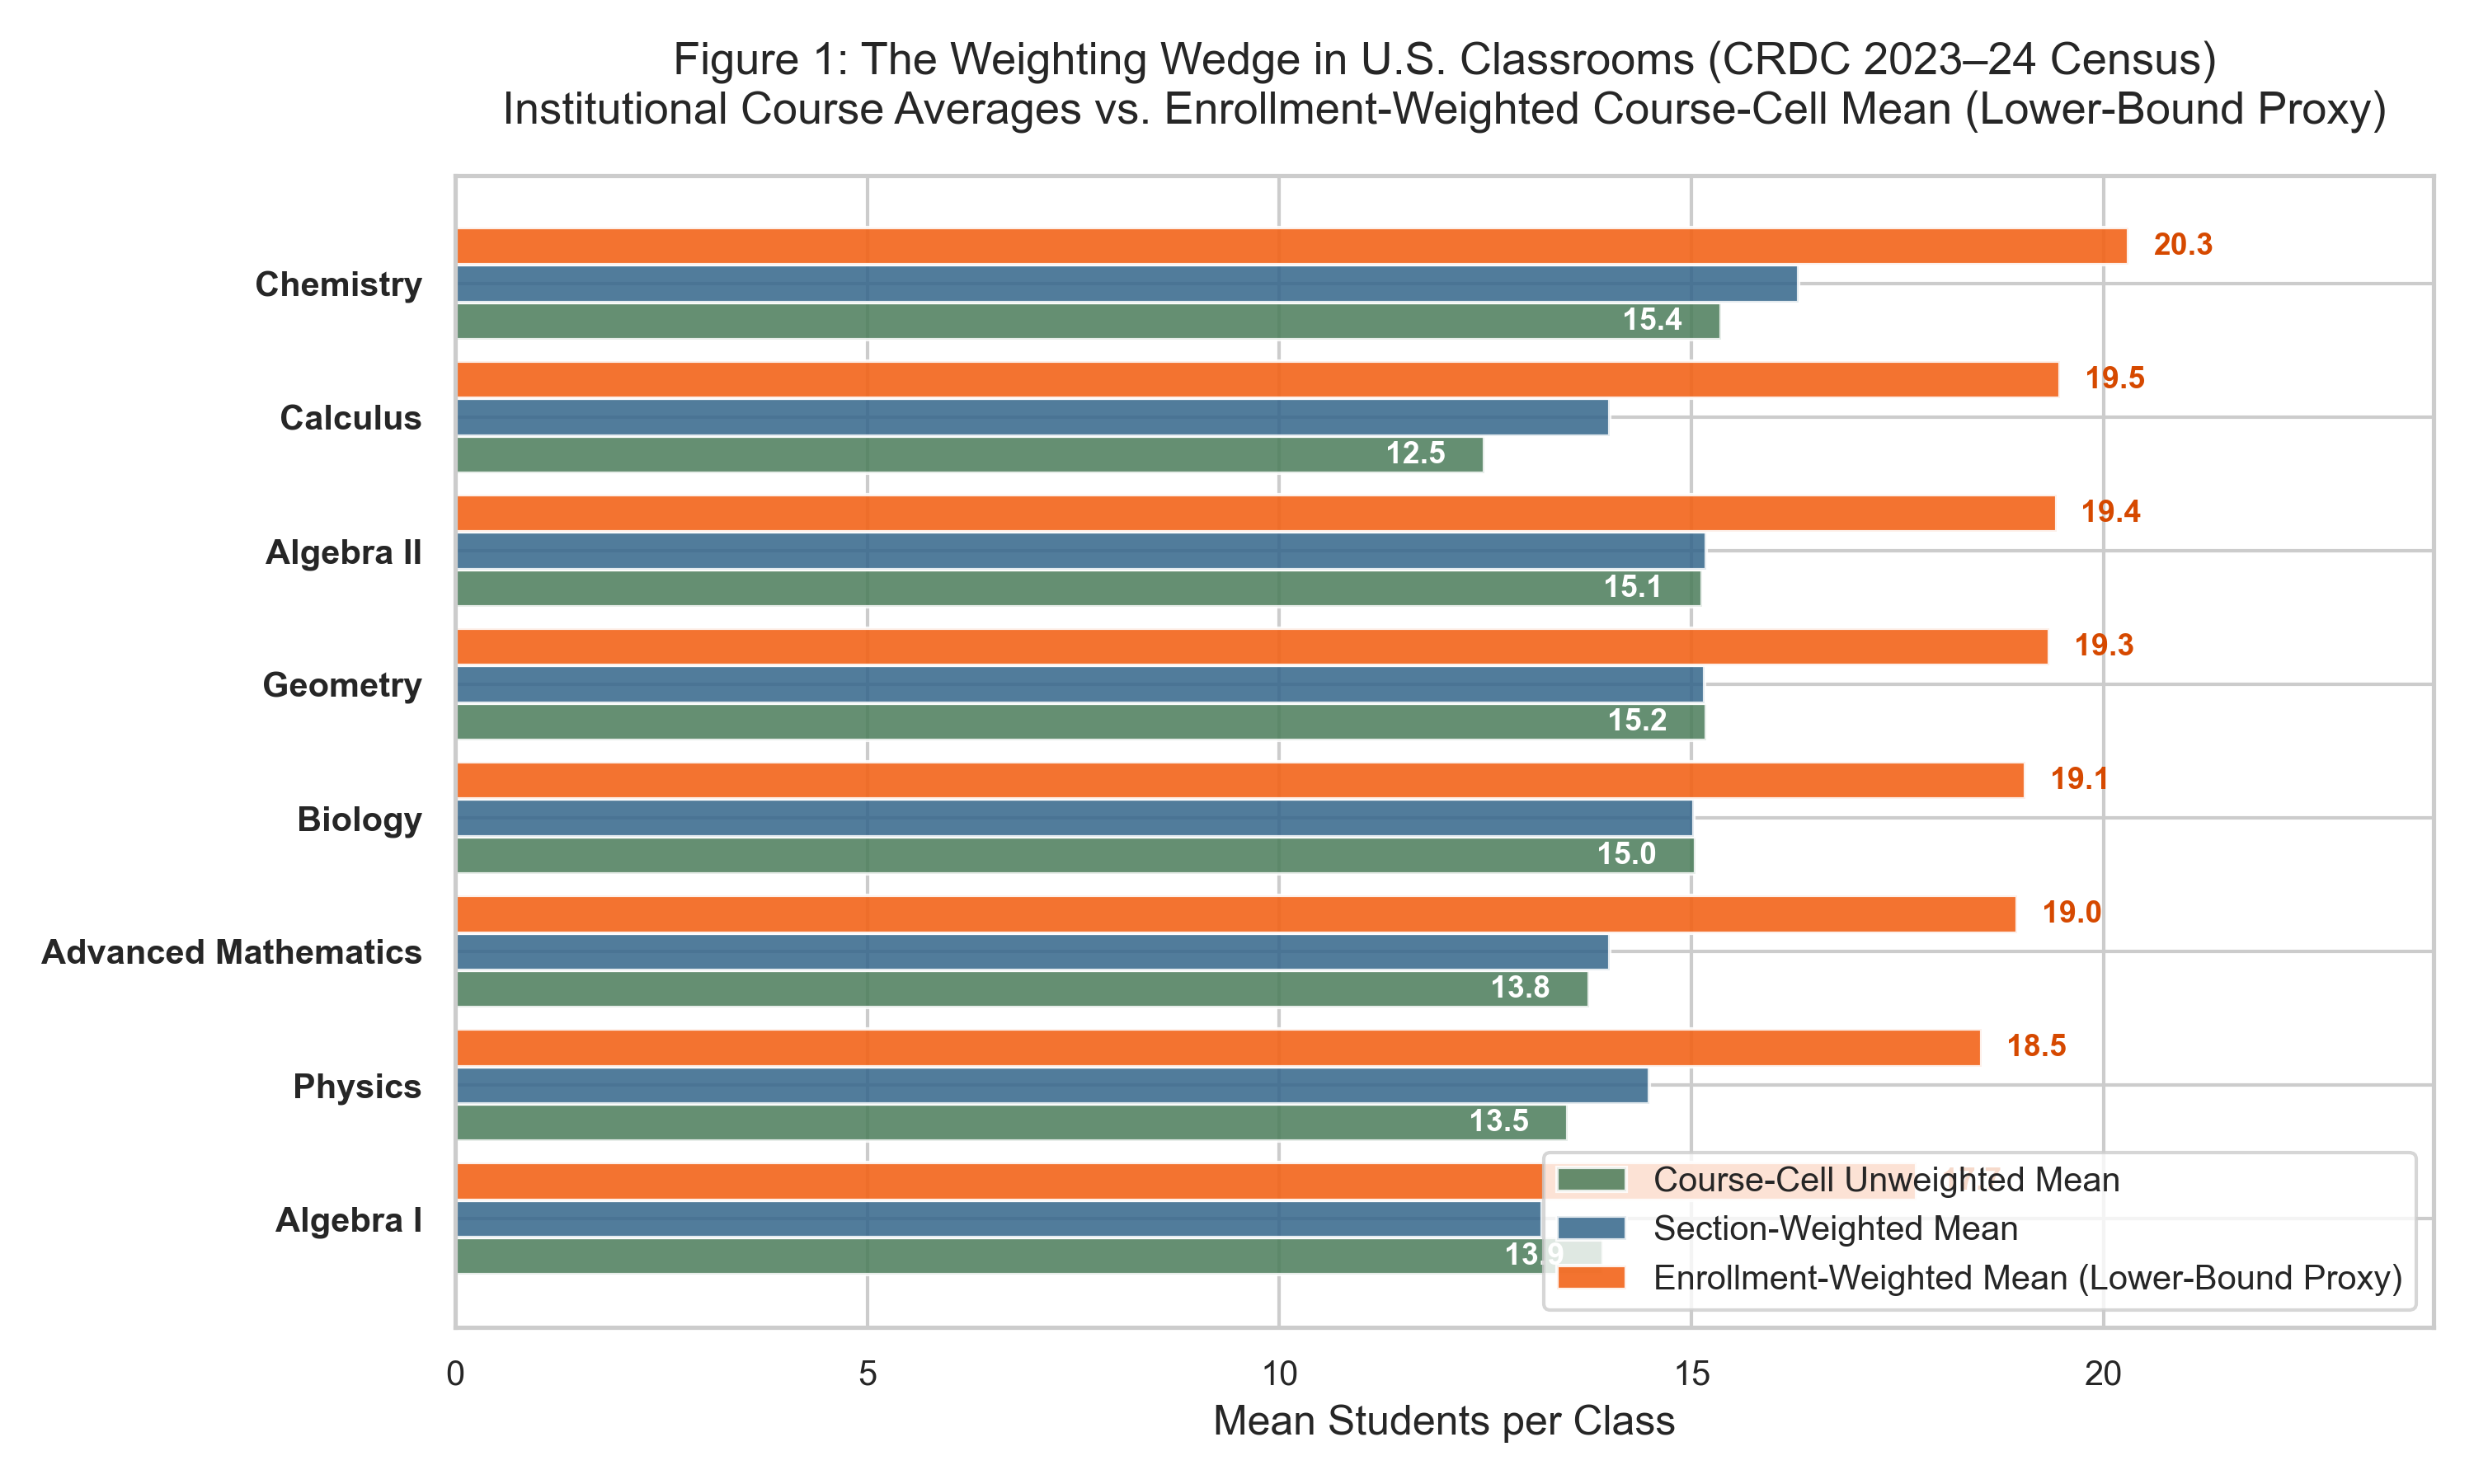

In [4]:
from IPython.display import Image
fig1_path = PROJECT_DIR / "artifacts" / "figures" / "fig01_weighting_wedge_divergence.png"
Image(filename=str(fig1_path))

## 4. The Upper Tail Matters: Concentration in School-Course Environments Averaging ≥25, ≥30, and ≥35

System-wide averages (e.g. "average class size is 18 to 20") obscure the meaningful population of secondary students concentrated in large learning environments.

Below we quantify the percentage of course cells vs. the **share of student enrollment** in school-course cells averaging ≥25, ≥30, and ≥35 students.

In [5]:
tail_table = []
for ccode in ["alg1", "geom", "alg2", "bio", "chem", "calc"]:
    sub = df_23[df_23["course_code"] == ccode]
    cname = sub["course_name"].iloc[0]
    tot_enr = sub["num_enrolled"].sum()
    cs = sub["mean_class_size"]
    
    tail_table.append({
        "Course": cname,
        "Cells >= 25": f"{(cs >= 25).mean() * 100:.1f}%",
        "Enrollment in Cells >= 25": f"{(sub.loc[cs >= 25, 'num_enrolled'].sum() / tot_enr) * 100:.1f}%",
        "Cells >= 30": f"{(cs >= 30).mean() * 100:.1f}%",
        "Enrollment in Cells >= 30": f"{(sub.loc[cs >= 30, 'num_enrolled'].sum() / tot_enr) * 100:.1f}%",
        "Enrollment in Cells >= 35": f"{(sub.loc[cs >= 35, 'num_enrolled'].sum() / tot_enr) * 100:.1f}%",
    })

pd.DataFrame(tail_table)

,Course,Cells >= 25,Enrollment in Cells >= 25,Cells >= 30,Enrollment in Cells >= 30,Enrollment in Cells >= 35
0,Algebra I,9.2%,15.1%,3.8%,6.4%,3.2%
1,Geometry,11.7%,19.3%,4.3%,6.9%,2.4%
2,Algebra II,12.4%,20.6%,4.5%,7.6%,2.7%
3,Biology,11.4%,18.4%,4.1%,6.4%,2.2%
4,Chemistry,12.5%,23.4%,4.3%,8.0%,2.1%
5,Calculus,9.4%,24.7%,3.7%,10.3%,3.0%


## 5. The Curriculum Hierarchy: School × Wave Fixed Effects

Does Geometry look different from Calculus? Do foundation graduation requirements systematically absorb larger class sizes even within the exact same school building during the exact same year?

### Model Specification:
$$ClassSize_{sct} = \alpha_{st} + \gamma_c + \epsilon_{sct}$$
where $\alpha_{st}$ represents **interactive school $\times$ wave fixed effects**, $\gamma_c$ are course effects, and standard errors are clustered at the school campus level with exact degrees-of-freedom correction.

### Reference Course Decision & Reference Date Audit:
In Phase 3.1, we audited the CRDC collection definitions and reference dates:
1. **Geometry as Preferred Reference:** In the 2023–24 CRDC, both class counts and enrollment are contemporaneous fall snapshots (October 1).
2. **Algebra I Reference Date Mismatch:** In 2023–24, Algebra I classes were counted October 1, but Algebra I enrollment was explicitly counted on a day at the end of the regular school year. Furthermore, in 2013–14, Algebra I spanned grades 7–12 rather than 9–12.
3. Therefore, **Geometry is our primary reference course**, and we report:
   - Full Hierarchy (Unweighted OLS)
   - Full Hierarchy (Section-Weighted WLS)
   - Sensitivity Model (Excluding Algebra I)

In [6]:
fe_path = PROJECT_DIR / "artifacts" / "tables" / "table04_fixed_effects_coefficients.csv"
df_fe = pd.read_csv(fe_path)

display_cols = ["sample", "weighting", "specification", "course_name", "coef_vs_geom", "std_err", "t_stat", "p_value"]

print("=== Kansas City Metro: Within-School Course Gradient (Ref: Geometry) ===")
df_fe[df_fe["sample"] == "Kansas City Metro"][display_cols]

=== Kansas City Metro: Within-School Course Gradient (Ref: Geometry) ===


,sample,weighting,specification,course_name,coef_vs_geom,std_err,t_stat,p_value
0,Kansas City Metro,Unweighted,Full Hierarchy (Ref: Geometry),Advanced Math,-2.224523,0.440436,-5.050733,4.401184e-07
1,Kansas City Metro,Unweighted,Full Hierarchy (Ref: Geometry),Algebra I,0.045460,0.386975,0.117475,9.064835e-01
2,Kansas City Metro,Unweighted,Full Hierarchy (Ref: Geometry),Algebra II,0.142986,0.325112,0.439805,6.600785e-01
3,Kansas City Metro,Unweighted,Full Hierarchy (Ref: Geometry),Biology,0.955654,0.404257,2.363977,1.807992e-02
4,Kansas City Metro,Unweighted,Full Hierarchy (Ref: Geometry),Calculus,-5.189269,0.600640,-8.639566,0.000000e+00
5,Kansas City Metro,Unweighted,Full Hierarchy (Ref: Geometry),Chemistry,0.347680,0.353502,0.983531,3.253464e-01
6,Kansas City Metro,Unweighted,Full Hierarchy (Ref: Geometry),Physics,-2.118665,0.624229,-3.394052,6.886653e-04
7,Kansas City Metro,Section-Weighted,Full Hierarchy (Ref: Geometry),Advanced Math,-1.873548,0.421241,-4.447691,8.679831e-06
8,Kansas City Metro,Section-Weighted,Full Hierarchy (Ref: Geometry),Algebra I,-1.245332,0.357399,-3.484429,4.931876e-04
9,Kansas City Metro,Section-Weighted,Full Hierarchy (Ref: Geometry),Algebra II,-0.563414,0.284508,-1.980307,4.766900e-02


In [7]:
print("=== Full National Panel: Within-School Course Gradient (Ref: Geometry) ===")
df_fe[df_fe["sample"] == "National Full Panel"][display_cols]

=== Full National Panel: Within-School Course Gradient (Ref: Geometry) ===


,sample,weighting,specification,course_name,coef_vs_geom,std_err,t_stat,p_value
40,National Full Panel,Unweighted,Full Hierarchy (Ref: Geometry),Advanced Math,-2.028769,0.034964,-58.024999,0.000000e+00
41,National Full Panel,Unweighted,Full Hierarchy (Ref: Geometry),Algebra I,-0.627572,0.026242,-23.914631,0.000000e+00
42,National Full Panel,Unweighted,Full Hierarchy (Ref: Geometry),Algebra II,0.027924,0.023085,1.209611,2.264280e-01
43,National Full Panel,Unweighted,Full Hierarchy (Ref: Geometry),Biology,0.262329,0.023808,11.018716,0.000000e+00
44,National Full Panel,Unweighted,Full Hierarchy (Ref: Geometry),Calculus,-4.635902,0.049194,-94.237193,0.000000e+00
45,National Full Panel,Unweighted,Full Hierarchy (Ref: Geometry),Chemistry,-0.213781,0.028662,-7.458769,8.726353e-14
46,National Full Panel,Unweighted,Full Hierarchy (Ref: Geometry),Physics,-2.404699,0.038241,-62.882501,0.000000e+00
47,National Full Panel,Section-Weighted,Full Hierarchy (Ref: Geometry),Advanced Math,-0.908582,0.038670,-23.495934,0.000000e+00
48,National Full Panel,Section-Weighted,Full Hierarchy (Ref: Geometry),Algebra I,-1.364469,0.027907,-48.892979,0.000000e+00
49,National Full Panel,Section-Weighted,Full Hierarchy (Ref: Geometry),Algebra II,0.382960,0.023163,16.533014,0.000000e+00


## 6. The Staffing Allocation Wedge: Actual Class Size vs. PTR

Pupil-teacher ratio (PTR) is an accounting construct: total school enrollment divided by total classroom teacher FTE. It is **not** class size.

Secondary departmentalized schedules mechanically drive a wedge between staffing ratios and classroom sizes:
- If high school teachers instruct 5 periods out of a 7-period day (reserving 2 periods for planning, collaboration, and duty), the theoretical schedule multiplier is $7/5 = 1.40\times$.
- In practice, observed Kansas City metro ratios range from **1.20× to 1.31×**, which is directionally consistent with the structural schedule wedge while accounting for co-teaching, specialty electives, and duty assignments.

Classroom sizes systematically exceed macro PTR across secondary high schools.

In [8]:
wedge_path = PROJECT_DIR / "artifacts" / "tables" / "table03_ptr_wedge_summary.csv"
df_wedge = pd.read_csv(wedge_path)

df_wedge[df_wedge["population"] == "Kansas City Metro"][
    ["wave", "n_observations", "mean_class_size", "mean_school_ptr", "mean_absolute_wedge", "mean_wedge_ratio", "pct_schools_class_size_gt_ptr"]
]

,wave,n_observations,mean_class_size,mean_school_ptr,mean_absolute_wedge,mean_wedge_ratio,pct_schools_class_size_gt_ptr
15,2015-16,735,19.118453,14.954955,4.163498,1.312927,74.285714
16,2017-18,766,17.094738,15.032384,2.062353,1.176059,63.446475
17,2020-21,759,15.532712,15.284469,0.248243,1.086453,46.376812
18,2021-22,728,16.031133,15.139011,0.892122,5.557186,56.181319
19,2023-24,775,16.577895,14.595947,1.981948,1.204419,64.645161


## 7. A Decade of Secondary Class Size (2013–14 to 2023–24): Longitudinal Comparability

### Longitudinal Panel Rules (Phase 3.1 Calibration):
1. **Primary Comparable Series (2015–16 to 2023–24):** Algebra I and Geometry fields covered grades 7–12 in 2013–14, but switched to grades 9–12 from 2015–16 onward. Therefore, 2015–16 onward is the primary strictly comparable longitudinal series for Algebra I and Geometry.
2. **Ten-Year Comparison (2013–14 to 2023–24):** Biology, Chemistry, and Calculus maintained consistent definitions across all six waves.
3. **Balanced Panel Robustness:** We verify trends against the balanced panel of 18,745 continuously operating secondary schools.

In [9]:
rob_path = PROJECT_DIR / "artifacts" / "tables" / "table06_balanced_panel_robustness.csv"
df_rob = pd.read_csv(rob_path)

print("=== Longitudinal Trajectory: Repeated Cross-Section vs. Balanced Panel ===")
df_rob[df_rob["course_code"].isin(["geom", "bio", "chem", "calc"])][
    ["wave", "course_name", "repeated_cross_cell_mean", "repeated_cross_seat_mean", "balanced_cell_mean", "balanced_seat_mean"]
].head(12)

=== Longitudinal Trajectory: Repeated Cross-Section vs. Balanced Panel ===


,wave,course_name,repeated_cross_cell_mean,repeated_cross_seat_mean,balanced_cell_mean,balanced_seat_mean
1,2013-14,Geometry,16.648670,21.090932,17.515527,21.084402
3,2013-14,Biology,16.705450,20.900282,17.555173,20.974910
4,2013-14,Chemistry,17.282801,21.553808,17.957227,21.626501
6,2015-16,Geometry,16.514025,20.979841,17.505355,21.104902
8,2015-16,Biology,16.907384,21.242513,17.829004,21.294415
9,2015-16,Chemistry,17.566743,22.312253,18.276806,22.385696
11,2017-18,Geometry,15.820333,20.328458,16.811598,20.409372
13,2017-18,Biology,16.002186,20.490165,16.970680,20.602742
14,2017-18,Chemistry,16.694447,21.407272,17.389768,21.492875
16,2020-21,Geometry,14.802168,18.918472,15.454389,18.878691


## 8. Empirical Findings and Pre-Registered Hypotheses Verdicts

| Pre-Registered Hypothesis | Prediction | Empirical Verdict | Key Supporting Evidence |
| :--- | :--- | :--- | :--- |
| **H1: PTR Divergence** | Actual class size systematically exceeds PTR in secondary schools. | **CONFIRMED** | Class sizes in Greater KC exceed PTR by +2.0 to +4.2 students; ratio is 1.20×–1.31×; 65%–74% of course cells exceed PTR. |
| **H2: Weighting Matters** | Teacher/cell averages are lower than the class size experienced by the average student. | **CONFIRMED** | Enrollment weighting systematically shifts estimates upward by +1.1 to +1.9 students (+5% to +10%). Crucially, this enrollment-weighted mean is mathematically a **lower-bound proxy** for true student-experienced section size. |
| **H3: The Upper Tail Matters** | System-wide averages obscure a meaningful population in large classes. | **CONFIRMED** | 15%–27% of students are enrolled in school-course cells averaging $\ge 25$, and 4%–8% in cells averaging $\ge 30$. |
| **H4: Class Size Persistence** | Secondary class sizes remained stable post-COVID rather than collapsing. | **CONFIRMED** | Core subjects stabilized at 19.5–20.5 students across 2021–22 and 2023–24 in both cross-sectional and balanced panels. |
| **H6: Within-School Nonlinearity / Curriculum Gradient** | Advanced electives have systematically smaller classes than foundation core courses within the same building. | **CONFIRMED** | Within the exact same school-year ($School \times Wave$ FE), Calculus classes are 2.7 to 4.6 students smaller than Geometry ($p < 0.001$), and Physics is 0.8 to 2.4 students smaller. |

---
*End of Study A Calibrated Notebook. Proceeding to Phase 3.1 Certification.*